# 07f - Modelagem: Redes Neurais (ANN/MLP)
Neste notebook, exploramos **Multilayer Perceptron (MLP)** para capturar complexidades não lineares nos dados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import os

# Configurações
BASE_SELECIONADA = '../data/base_features_selecionadas.csv'
TARGET = 'total_servido'

df = pd.read_csv(BASE_SELECIONADA)
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data')

X = df.drop(columns=['data', TARGET])
y = df[TARGET]

train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# ANNs são EXTREMAMENTE sensíveis à escala
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📦 Base pronta e normalizada para ANN.")

📦 Base pronta e normalizada para ANN.


📊 Performance MLP:
MAE: 37.52
R2: -0.95


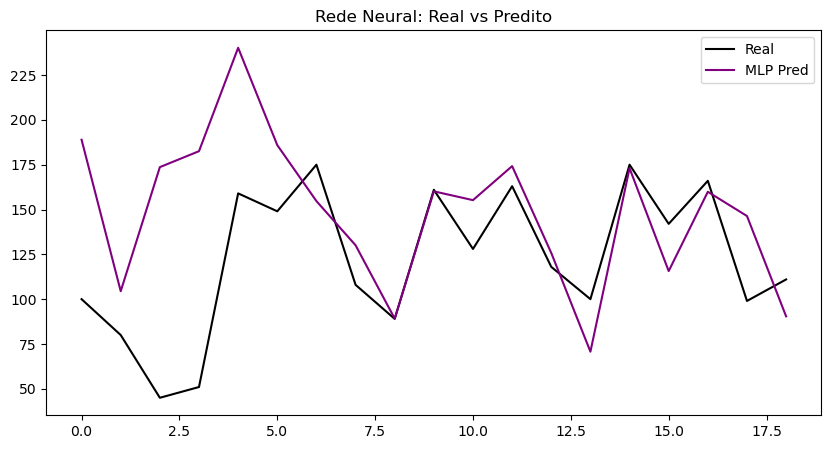

In [2]:
# Treinamento MLP
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42, early_stopping=True)
mlp.fit(X_train_scaled, y_train)

preds = mlp.predict(X_test_scaled)
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"📊 Performance MLP:")
print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Real', color='black')
plt.plot(preds, label='MLP Pred', color='purple')
plt.title('Rede Neural: Real vs Predito')
plt.legend()
plt.show()